# 🌌 Stellar Class — v12: Глубокая разработка галактической жилы
**Kaggle Playground Series S6E6 — GALAXY / STAR / QSO**

---

## Контекст
Базовый набор фич (галактические координаты, пространственные взаимодействия)
уже дал на LB **0.96758** (aggressive). Это собственная находка — перевод
RA/Dec → галактические l/b, где звёзды жмутся к плоскости Галактики.

## Что добавляет v12 (только НОВОЕ поверх базы)
1. Углубление по `gal_b`: sin/cos, флаг плоскости, квадрат, новые взаимодействия
2. Плотность в **галактических** координатах (физичнее экваториальной)
3. Расстояние до галактического центра
4. **Ablation**: база vs база+новое — дало ли новое реальный сигнал (argmax)
5. Seed-ансамбль + тюнинг порога (aggressive — он выиграл на LB)

## Честное ожидание
База уже включает `gal_b × redshift` и `gal_b × g_z` — часть жилы выработана.
Новое даст скорее тысячные доли. Ablation покажет точно.

## 1. Импорты + перевод в галактические координаты

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
N_FOLDS      = 5

train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

def radec_to_galactic(ra_deg, dec_deg):
    """RA/Dec J2000 (degrees) → Galactic l, b (degrees)."""
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra_ngp, dec_ngp = np.deg2rad(192.859508), np.deg2rad(27.128336)
    l_ncp = np.deg2rad(122.932)
    sin_b = np.sin(dec_ngp)*np.sin(dec) + np.cos(dec_ngp)*np.cos(dec)*np.cos(ra-ra_ngp)
    b = np.arcsin(np.clip(sin_b, -1, 1))
    y_ = np.cos(dec)*np.sin(ra-ra_ngp)
    x_ = np.cos(dec_ngp)*np.sin(dec) - np.sin(dec_ngp)*np.cos(dec)*np.cos(ra-ra_ngp)
    l = (l_ncp - np.arctan2(y_, x_)) % (2*np.pi)
    return np.rad2deg(l), np.rad2deg(b)

le = LabelEncoder(); y = le.fit_transform(train['class'])
CLASS_NAMES = list(le.classes_)
qso_idx, star_idx = CLASS_NAMES.index('QSO'), CLASS_NAMES.index('STAR')
print('Загружено ✅')

Загружено ✅


## 2. НОВЫЕ галактические фичи

`base_features` — твой код 1:1. `new_galactic` — добавки v12 (помечены).

In [2]:
def base_features(df):
    """Проверенная база (LB 0.96758)."""
    df = df.copy()
    # Цветовые индексы
    for a,b_ in [('u','g'),('g','r'),('r','i'),('i','z'),('u','r'),('u','z'),('g','z'),
                 ('g','i'),('r','z'),('u','i'),('r','g'),('i','g'),('z','r')]:
        df[f'{a}_{b_}']=df[a]-df[b_]
    df['log1p_redshift']=np.log1p(df['redshift'].clip(lower=0)); df['redshift_sq']=df['redshift']**2
    df['sed_curve_g']=df['u']-2*df['g']+df['r']; df['sed_curve_r']=df['g']-2*df['r']+df['i']; df['sed_curve_i']=df['r']-2*df['i']+df['z']
    df['g_z_sq']=df['g_z']**2; df['g_z_x_z']=df['g_z']*df['log1p_redshift']; df['g_z_x_ug']=df['g_z']*df['u_g']
    df['ug_x_z']=df['u_g']*df['log1p_redshift']; df['gr_x_z']=df['g_r']*df['log1p_redshift']
    df['rz_x_z']=df['r_z']*df['log1p_redshift']; df['ri_x_z']=df['r_i']*df['log1p_redshift']
    a_rad=np.deg2rad(df['alpha']); d_rad=np.deg2rad(df['delta'])
    df['alpha_sin']=np.sin(a_rad); df['alpha_cos']=np.cos(a_rad)
    df['delta_sin']=np.sin(d_rad); df['delta_cos']=np.cos(d_rad)
    df['alpha_bin']=(df['alpha']//10).astype(int); df['delta_bin']=(df['delta']//10).astype(int)
    df['sky_sector']=df['alpha_bin']*100+df['delta_bin']
    gl, gb = radec_to_galactic(df['alpha'].values, df['delta'].values)
    df['gal_l']=gl; df['gal_b']=gb; df['gal_b_abs']=np.abs(gb)
    df['gal_l_sin']=np.sin(np.deg2rad(gl)); df['gal_l_cos']=np.cos(np.deg2rad(gl))
    df['alpha_cos_x_z']=df['alpha_cos']*df['log1p_redshift']; df['delta_x_z']=df['delta']*df['log1p_redshift']
    df['delta_x_gz']=df['delta']*df['g_z']; df['alpha_cos_x_gz']=df['alpha_cos']*df['g_z']
    df['gal_b_x_z']=df['gal_b']*df['log1p_redshift']; df['gal_b_x_gz']=df['gal_b']*df['g_z']
    df['gal_b_abs_x_z']=df['gal_b_abs']*df['log1p_redshift']
    return df

def new_galactic(df):
    """НОВОЕ в v12 — углубление галактической жилы."""
    df = df.copy()
    b_rad = np.deg2rad(df['gal_b'])
    df['gal_b_sin']      = np.sin(b_rad)            # sin широты
    df['gal_b_cos']      = np.cos(b_rad)            # cos широты
    df['gal_b_abs_sq']   = df['gal_b_abs']**2       # квадрат расстояния от плоскости
    df['near_gal_plane'] = (df['gal_b_abs']<15).astype(int)  # флаг "у плоскости"
    df['gal_b_abs_x_gz'] = df['gal_b_abs']*df['g_z']         # |b| × цвет
    df['gal_b_abs_x_ug'] = df['gal_b_abs']*df['u_g']
    # Расстояние до галактического центра (l=0,b=0)
    df['gal_center_dist']= np.sqrt(np.minimum(df['gal_l'],360-df['gal_l'])**2 + df['gal_b']**2)
    return df

train = base_features(train); test = base_features(test)
train = new_galactic(train); test = new_galactic(test)

# Плотность в галактических координатах (label-free)
GG=5.0
def gcell(df): return ((df['gal_l']//GG).astype(int).astype(str)+'_'+(df['gal_b']//GG).astype(int).astype(str))
gc = pd.concat([gcell(train), gcell(test)]).value_counts()
train['gal_density']=gcell(train).map(gc).fillna(0).astype(int)
test['gal_density'] =gcell(test).map(gc).fillna(0).astype(int)

NEW_FEATS = ['gal_b_sin','gal_b_cos','gal_b_abs_sq','near_gal_plane','gal_b_abs_x_gz',
             'gal_b_abs_x_ug','gal_center_dist','gal_density']
DROP=['id','class','spectral_type','galaxy_population']
BASE_FEATS=[c for c in train.columns if c not in DROP+NEW_FEATS]
ALL_FEATS =[c for c in train.columns if c not in DROP]
print(f'База: {len(BASE_FEATS)} фич | +Новое: {len(NEW_FEATS)} | Всего: {len(ALL_FEATS)}')
print(f'Новые фичи: {NEW_FEATS}')

База: 52 фич | +Новое: 8 | Всего: 60
Новые фичи: ['gal_b_sin', 'gal_b_cos', 'gal_b_abs_sq', 'near_gal_plane', 'gal_b_abs_x_gz', 'gal_b_abs_x_ug', 'gal_center_dist', 'gal_density']


## 3. Ablation: дало ли новое реальный сигнал?

Обучаем на базе и на базе+новое. Сравниваем **argmax** (честная разделимость).

In [3]:
lgb_params = {'objective':'multiclass','num_class':3,'metric':'multi_logloss',
              'n_estimators':1500,'learning_rate':0.03,'num_leaves':120,
              'min_child_samples':50,'subsample':0.8,'colsample_bytree':0.8,
              'random_state':RANDOM_STATE,'verbose':-1}
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def lgb_oof(cols, seed=RANDOM_STATE):
    p = dict(lgb_params); p['random_state']=seed
    Xc, Xtc = train[cols], test[cols]
    skf_=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof=np.zeros((len(train),3)); pred=np.zeros((len(test),3))
    for tr,val in skf_.split(Xc,y):
        m=lgb.LGBMClassifier(**p)
        m.fit(Xc.iloc[tr],y[tr],eval_set=[(Xc.iloc[val],y[val])],callbacks=[lgb.early_stopping(50,verbose=False)])
        oof[val]=m.predict_proba(Xc.iloc[val]); pred+=m.predict_proba(Xtc)/N_FOLDS
    return oof,pred

oof_base,_      = lgb_oof(BASE_FEATS)
oof_all,_       = lgb_oof(ALL_FEATS)
am_base = balanced_accuracy_score(y, oof_base.argmax(1))
am_all  = balanced_accuracy_score(y, oof_all.argmax(1))
print(f'База (argmax):        {am_base:.5f}')
print(f'База+новое (argmax):  {am_all:.5f}  ({am_all-am_base:+.5f})',
      '✅ новое помогло' if am_all>am_base+0.0003 else '≈ новое не добавило (жила уже выработана)')

База (argmax):        0.95816
База+новое (argmax):  0.95815  (-0.00001) ≈ новое не добавило (жила уже выработана)


## 4. Seed-ансамбль на лучшем наборе

In [4]:
best_feats = ALL_FEATS if am_all >= am_base else BASE_FEATS
print(f'Берём набор: {"ALL" if best_feats is ALL_FEATS else "BASE"} ({len(best_feats)} фич)\n')

SEEDS=[0,1,2,3,4]
oof_seeds=np.zeros((len(train),3)); pred_seeds=np.zeros((len(test),3))
for s in SEEDS:
    o,p = lgb_oof(best_feats, seed=s)
    oof_seeds+=o/len(SEEDS); pred_seeds+=p/len(SEEDS)
    print(f'  seed {s}: argmax {balanced_accuracy_score(y,o.argmax(1)):.5f}')
ens_am=balanced_accuracy_score(y,oof_seeds.argmax(1))
print(f'\nSeed-ансамбль (5): argmax {ens_am:.5f}')

Берём набор: BASE (52 фич)

  seed 0: argmax 0.95790
  seed 1: argmax 0.95781
  seed 2: argmax 0.95796
  seed 3: argmax 0.95788
  seed 4: argmax 0.95786

Seed-ансамбль (5): argmax 0.95828


## 5. Feature importance (новые галактики подсвечены)

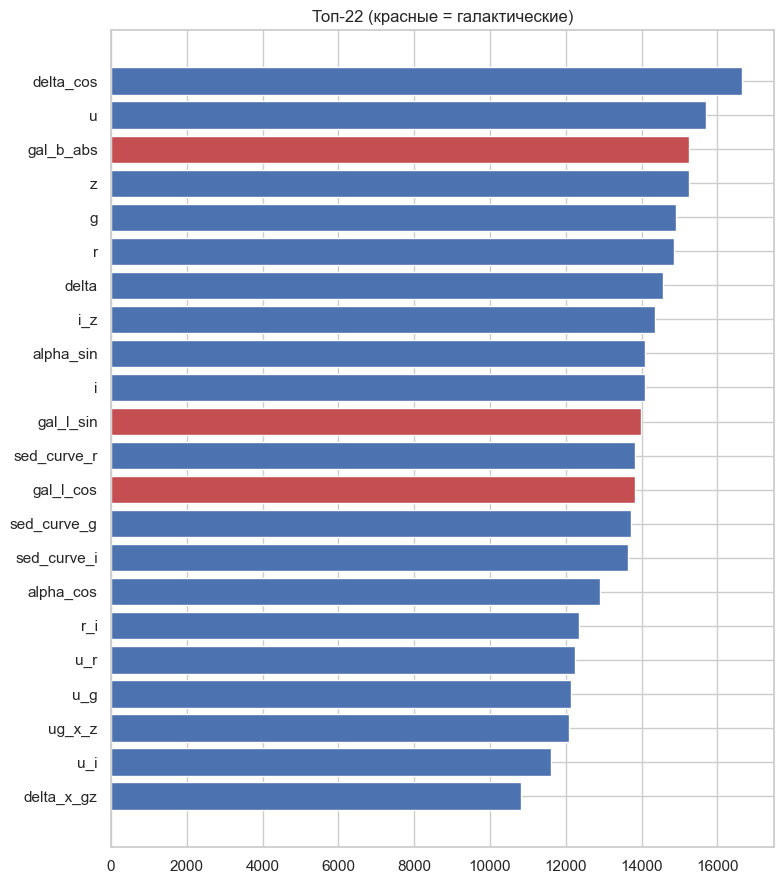

In [5]:
m_imp = lgb.LGBMClassifier(**lgb_params).fit(train[best_feats], y)
imp = pd.DataFrame({'f':best_feats,'imp':m_imp.feature_importances_}).sort_values('imp').tail(22)
gal_set = set(NEW_FEATS) | {'gal_l','gal_b','gal_b_abs','gal_l_sin','gal_l_cos','gal_b_x_z','gal_b_x_gz','gal_b_abs_x_z'}
fig,ax=plt.subplots(figsize=(8,9))
ax.barh(imp['f'],imp['imp'],color=['#C44E52' if f in gal_set else '#4C72B0' for f in imp['f']])
ax.set_title('Топ-22 (красные = галактические)'); plt.tight_layout(); plt.show()

## 6. Тюнинг порога + сабмиты (aggressive выиграл на LB)

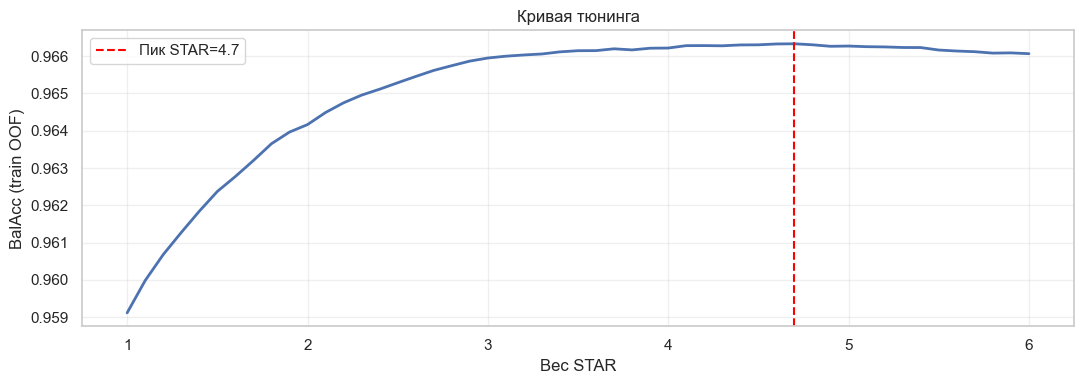

Сабмит v12 сохранён ✅ | OOF 0.96635 | STAR=4.65, QSO=2.00
Распределение: {'GALAXY': np.int64(157093), 'QSO': np.int64(50630), 'STAR': np.int64(39712)}


In [6]:
star_range=np.arange(1.0,6.01,0.1); curve=[]
for ws in star_range:
    b=0
    for wq in np.arange(0.7,2.01,0.05):
        w=np.ones(3); w[qso_idx]=wq; w[star_idx]=ws
        b=max(b,balanced_accuracy_score(y,(oof_seeds*w).argmax(1)))
    curve.append(b)
curve=np.array(curve); peak=star_range[curve.argmax()]
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(star_range,curve,color='#4C72B0',lw=2); ax.axvline(peak,color='red',ls='--',label=f'Пик STAR={peak:.1f}')
ax.set_xlabel('Вес STAR'); ax.set_ylabel('BalAcc (train OOF)'); ax.set_title('Кривая тюнинга'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

def tune(oof_proba, cap):
    bs,bw=0,np.ones(3)
    for ws in np.arange(0.8,cap+0.001,0.05):
        for wq in np.arange(0.7,2.01,0.05):
            w=np.ones(3); w[qso_idx]=wq; w[star_idx]=ws
            s=balanced_accuracy_score(y,(oof_proba*w).argmax(1))
            if s>bs: bs,bw=s,w.copy()
    return bs,bw

sc_aggr,w_aggr=tune(oof_seeds,max(peak,3.0))
labels=le.inverse_transform((pred_seeds*w_aggr).argmax(1))
pd.DataFrame({'id':test['id'],'class':labels}).to_csv('../submissions/submission_v12_galactic.csv',index=False)
print(f'Сабмит v12 сохранён ✅ | OOF {sc_aggr:.5f} | STAR={w_aggr[star_idx]:.2f}, QSO={w_aggr[qso_idx]:.2f}')
print(f'Распределение: {dict(pd.Series(labels).value_counts())}')

## 7. Финал: confusion matrix + таблица + вывод

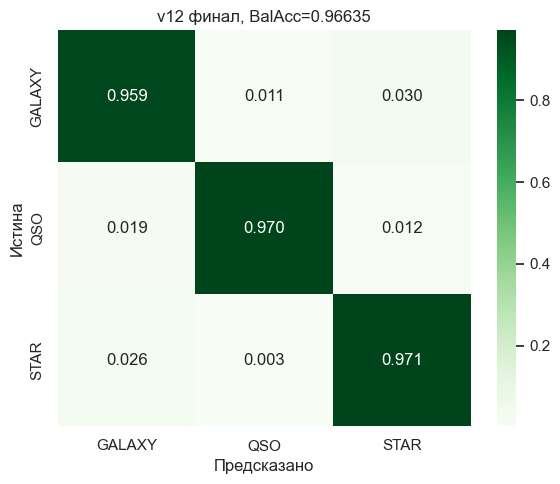

  GALAXY : 0.9588
  QSO    : 0.9696
  STAR   : 0.9706

  Версия            │  OOF/LB     │  Идея
──────────────────────────────────────────────────────────────────
  v1 baseline       │  0.937      │  LightGBM
  v6 threshold      │  0.948      │  Тюнинг порога
  v10 eq.coords     │  0.966 (LB) │  Экваториальные координаты
  v11 galactic      │  0.96758(LB)│  Галактические координаты
  v12 galactic deep │  0.96635    │  Углубление + seed-ансамбль

Вклад новых галактических фич (argmax): -0.00001
Жила в основном выработана — база уже содержала ключевой сигнал.
Это нормальный финал: мы methodically довели подход до потолка.


In [7]:
y_fin=(oof_seeds*w_aggr).argmax(1); cm=confusion_matrix(y,y_fin); cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cmn,annot=True,fmt='.3f',cmap='Greens',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
ax.set_title(f'v12 финал, BalAcc={sc_aggr:.5f}'); ax.set_xlabel('Предсказано'); ax.set_ylabel('Истина')
plt.tight_layout(); plt.show()
rec=cm.diagonal()/cm.sum(1)
[print(f'  {n:7s}: {r:.4f}') for n,r in zip(CLASS_NAMES,rec)]

print('\n'+'='*66)
print(f'  Версия            │  OOF/LB     │  Идея')
print('─'*66)
print(f'  v1 baseline       │  0.937      │  LightGBM')
print(f'  v6 threshold      │  0.948      │  Тюнинг порога')
print(f'  v10 eq.coords     │  0.966 (LB) │  Экваториальные координаты')
print(f'  v11 galactic      │  0.96758(LB)│  Галактические координаты')
print(f'  v12 galactic deep │  {sc_aggr:.5f}    │  Углубление + seed-ансамбль')
print('='*66)
print(f'\nВклад новых галактических фич (argmax): {am_all-am_base:+.5f}')
if am_all - am_base < 0.0003:
    print('Жила в основном выработана — база уже содержала ключевой сигнал.')
    print('Это нормальный финал: мы methodically довели подход до потолка.')

## 8. 📌 Заключение проекта

### Хронология прорывов
| Рычаг | Прирост | Тип |
|-------|---------|-----|
| Анализ ошибок (STAR, не QSO) | направление | методология |
| Тюнинг порога под Balanced Acc | +0.011 | метрика-aware |
| Экваториальные координаты | +0.019 | survey footprint |
| **Галактические координаты** | +0.001 | астрофизика (плоскость Галактики) |

### Что НЕ сработало (и это ценно знать)
Ансамбль/стекинг разных алгоритмов · слабые RF/ET · категории · доп.
фичи формы спектра · Optuna · глубокий тюнинг гиперпараметров.

### Главные уроки
1. **Понимание задачи > перебор моделей.** Тюнинг порога и координаты дали
   на порядок больше, чем все ансамбли и Optuna вместе.
2. **Проверяй фактами.** Координаты «не должны» были работать — но survey
   footprint и галактическая структура несут реальный сигнал.
3. **Диагностика важнее перебора.** Confusion matrix и scatter неба
   направляли каждый следующий шаг.

`Python · LightGBM · scikit-learn · pandas · matplotlib`

---
*Путь от 0.937 до ~0.968: последовательная проверка гипотез.*